In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


#sns.set_style('whitegrid')
#plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_excel(
    r'C:\Users\opiyo\Documents\Datasets\super_store_data.xlsx',
    engine='openpyxl'
)

df.head()

,Order ID,Order Date,Ship Date,Duration days,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,CA-2017-152156,2017-11-08,2017-11-11,3,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,CA-2017-152156,2017-11-08,2017-11-11,3,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,CA-2017-138688,2017-06-12,2017-06-16,4,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,US-2016-108966,2016-10-11,2016-10-18,7,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,US-2016-108966,2016-10-11,2016-10-18,7,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
#Cleaning- Here we check for duplicates and missing values
df.duplicated().sum()

np.int64(1)

In [8]:
df = df.drop_duplicates()
df.isna().sum()

Order ID          0
Order Date        0
Ship Date         0
Duration days     0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [9]:
#postal code has few blanks....but we'll not need that in our analysis
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df.head()

,Order ID,Order Date,Ship Date,Duration days,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,CA-2017-152156,2017-11-08,2017-11-11,3,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,CA-2017-152156,2017-11-08,2017-11-11,3,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,CA-2017-138688,2017-06-12,2017-06-16,4,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,US-2016-108966,2016-10-11,2016-10-18,7,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,US-2016-108966,2016-10-11,2016-10-18,7,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [12]:
#Here i want us to check shipping efficiency...if big order takes longer to ship out and what happens
df['order_size_bucket'] = pd.qcut(df['Sales'], q=4, labels=['Small', 'Medium', 'Large', 'X-Large'])

shipping_by_size = df.groupby('order_size_bucket', observed=False)['Duration days'].agg(['mean', 'count']).round(2)
shipping_by_size.columns = ['avg_ship_days', 'num_orders']
shipping_by_size

,avg_ship_days,num_orders
order_size_bucket,,
Small,3.96,2451
Medium,4.01,2449
Large,3.93,2449
X-Large,3.94,2450


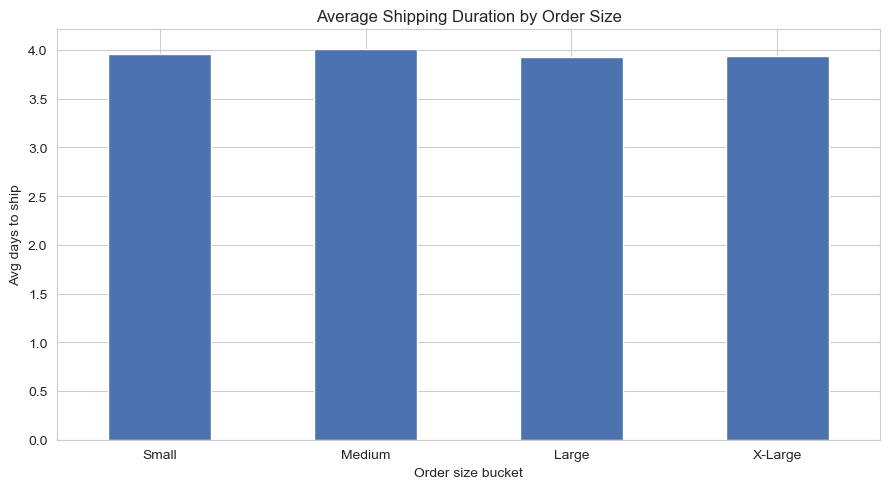

In [16]:
import os

# Create an 'outputs' folder inside your CURRENT working directory
os.makedirs('outputs', exist_ok=True)

# Build the plot
fig, ax = plt.subplots()
shipping_by_size['avg_ship_days'].plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Average Shipping Duration by Order Size')
ax.set_xlabel('Order size bucket')
ax.set_ylabel('Avg days to ship')
plt.xticks(rotation=0)
plt.tight_layout()

# Save into the local outputs folder
plt.savefig('outputs/shipping_vs_order_size.png', dpi=150)
plt.show()

In [ ]:
#average shipping time barely moves across order size buckets, so order size on its own isn't hurting or helping delivery speed. Ship Mode is the real driver of how fast orders go out, which makes sense.. that's the thing customers are actually choosing.

In [17]:
#Deadweight products- This are products that sit in the bottom 10% of total sales
product_sales = df.groupby(['Product ID', 'Product Name', 'Category', 'Sub-Category'])['Sales'].sum().reset_index()
product_sales = product_sales.sort_values('Sales')

cutoff = product_sales['Sales'].quantile(0.10)
deadweight = product_sales[product_sales['Sales'] <= cutoff]

print(f'{len(deadweight)} products ({len(deadweight) / len(product_sales):.1%} of the catalog) '
      f'sit at or below the bottom 10% sales cutoff of ${cutoff:.2f}')
print(f'Combined they bring in ${deadweight["Sales"].sum():,.2f}, '
      f'which is {deadweight["Sales"].sum() / product_sales["Sales"].sum():.2%} of total revenue')

190 products (10.0% of the catalog) sit at or below the bottom 10% sales cutoff of $45.06
Combined they bring in $5,034.64, which is 0.22% of total revenue


In [18]:
deadweight_by_category = deadweight.groupby('Category').agg(
    products=('Product ID', 'count'),
    revenue=('Sales', 'sum')
).sort_values('revenue', ascending=False)
deadweight_by_category

,products,revenue
Category,,
Office Supplies,166,4350.135
Furniture,10,343.758
Technology,14,340.750


In [19]:
deadweight.sort_values('Sales').head(15)[['Product Name', 'Category', 'Sub-Category', 'Sales']]

,Product Name,Category,Sub-Category,Sales
427,Eureka Disposable Bags for Sanitaire Vibra Gro...,Office Supplies,Appliances,1.624
1001,Avery 5,Office Supplies,Labels,5.760
1029,Xerox 20,Office Supplies,Paper,6.480
875,Grip Seal Envelopes,Office Supplies,Envelopes,7.072
1468,Acme Serrated Blade Letter Opener,Office Supplies,Supplies,7.632
616,Avery Hi-Liter Pen Style Six-Color Fluorescent...,Office Supplies,Art,7.700
515,Avery Hi-Liter Comfort Grip Fluorescent Highli...,Office Supplies,Art,7.800
1260,Xerox 1989,Office Supplies,Paper,7.968
591,4009 Highlighters,Office Supplies,Art,8.040
931,Stockwell Gold Paper Clips,Office Supplies,Fasteners,8.096


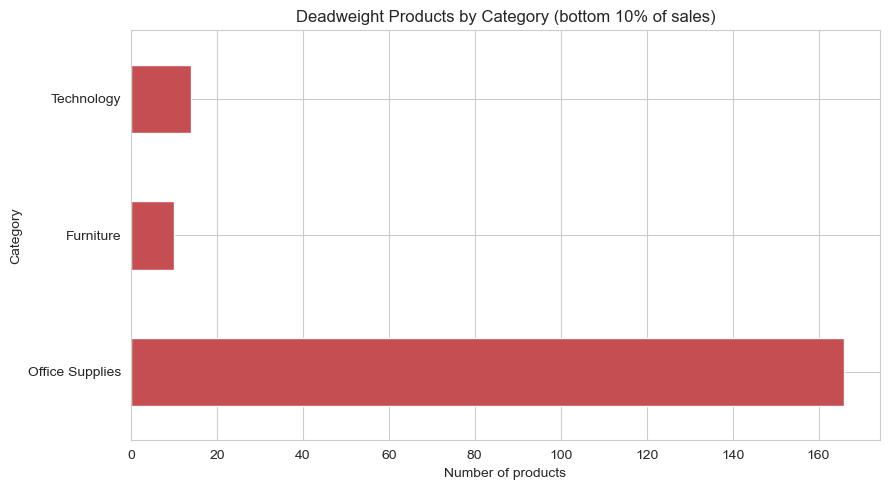

In [21]:
import os

# Ensure local outputs directory exists
os.makedirs('outputs', exist_ok=True)

fig, ax = plt.subplots()
deadweight_by_category['products'].plot(kind='barh', ax=ax, color='#C44E52')
ax.set_title('Deadweight Products by Category (bottom 10% of sales)')
ax.set_xlabel('Number of products')
plt.tight_layout()

# Save locally to outputs/
plt.savefig('outputs/deadweight_products.png', dpi=150)
plt.show()

In [22]:
#Stores driving 80% of revenue
def top_states_for_80_percent(segment_df):
    state_sales = segment_df.groupby('State')['Sales'].sum().sort_values(ascending=False)
    cum_share = state_sales.cumsum() / state_sales.sum()
    num_states = (cum_share <= 0.80).sum() + 1  # +1 to include the state that crosses the line
    return state_sales, num_states

for segment in df['Segment'].unique():
    seg_df = df[df['Segment'] == segment]
    state_sales, num_states = top_states_for_80_percent(seg_df)
    total_states = state_sales.shape[0]
    print(f'{segment}: top {num_states} of {total_states} states drive 80% of revenue')

Consumer: top 15 of 47 states drive 80% of revenue
Corporate: top 16 of 45 states drive 80% of revenue
Home Office: top 17 of 48 states drive 80% of revenue


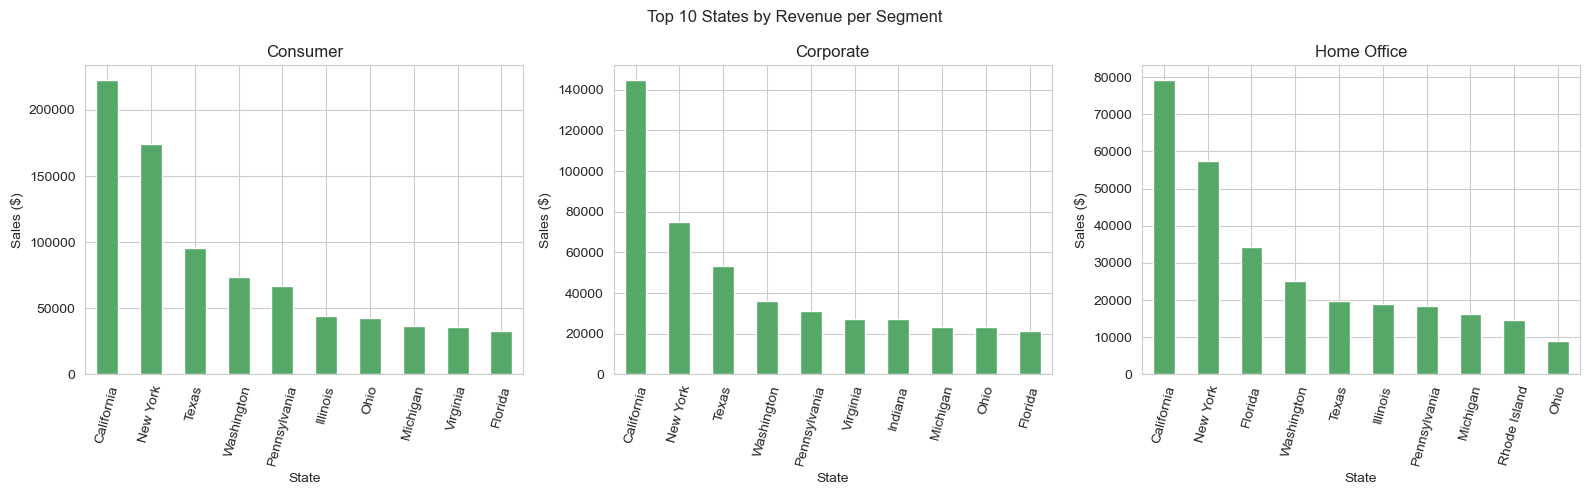

In [24]:
import os

# Ensure the local outputs directory exists
os.makedirs('outputs', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, segment in zip(axes, df['Segment'].unique()):
    seg_df = df[df['Segment'] == segment]
    state_sales, num_states = top_states_for_80_percent(seg_df)
    top10 = state_sales.head(10)
    top10.plot(kind='bar', ax=ax, color='#55A868')
    ax.set_title(segment)
    ax.set_ylabel('Sales ($)')
    ax.tick_params(axis='x', rotation=75)

plt.suptitle('Top 10 States by Revenue per Segment')
plt.tight_layout()

# Save locally to outputs/
plt.savefig('outputs/top_states_by_segment.png', dpi=150)
plt.show()

In [25]:
#underperforming regions
region_summary = df.groupby('Region').agg(
    total_revenue=('Sales', 'sum'),
    num_orders=('Order ID', 'nunique'),
    avg_order_value=('Sales', 'mean')
).round(2).sort_values('total_revenue', ascending=False)

region_summary['revenue_share'] = (region_summary['total_revenue'] / region_summary['total_revenue'].sum()).round(3)
region_summary

,total_revenue,num_orders,avg_order_value,revenue_share
Region,,,,
West,710219.68,1587,226.18,0.314
East,669237.35,1369,240.39,0.296
Central,492646.91,1156,216.36,0.218
South,389151.46,810,243.52,0.172


In [28]:
avg_revenue = region_summary['total_revenue'].mean()
region_summary['vs_avg'] = (region_summary['total_revenue'] - avg_revenue).round(2)
underperforming = region_summary[region_summary['total_revenue'] < avg_revenue]
underperforming

,total_revenue,num_orders,avg_order_value,revenue_share,vs_avg
Region,,,,,
Central,492646.91,1156,216.36,0.218,-72666.94
South,389151.46,810,243.52,0.172,-176162.39


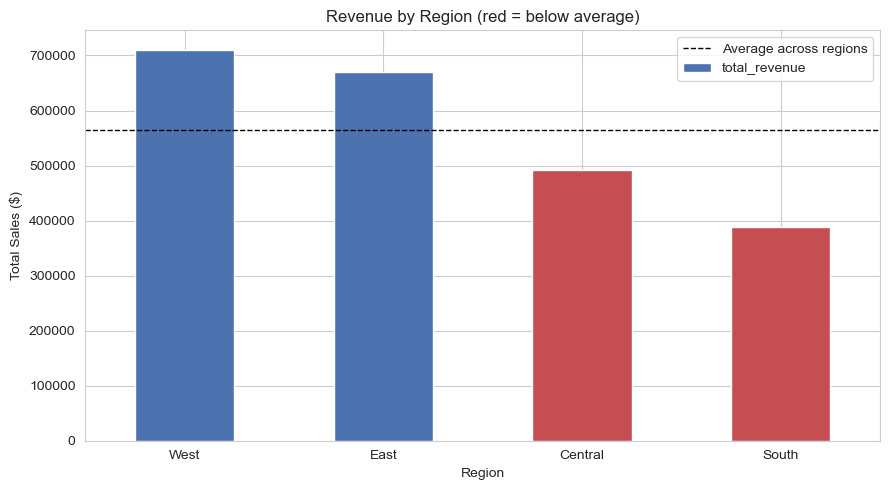

In [29]:
import os

# Ensure local outputs directory exists
os.makedirs('outputs', exist_ok=True)

fig, ax = plt.subplots()
colors = ['#C44E52' if r in underperforming.index else '#4C72B0' for r in region_summary.index]
region_summary['total_revenue'].plot(kind='bar', ax=ax, color=colors)
ax.axhline(avg_revenue, color='black', linestyle='--', linewidth=1, label='Average across regions')
ax.set_title('Revenue by Region (red = below average)')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()

# Save locally to outputs/
plt.savefig('outputs/regional_revenue.png', dpi=150)
plt.show()